# Inverse Designed Grating Coupler using PhotonForge and Tidy3D

In this notebook, we provide an example of fabrication-aware inverse design using [PhotonForge](https://www.flexcompute.com/photonforge) and Tidy3D's [inverse design framework](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd0Overview/).

[PhotonForge](https://www.flexcompute.com/photonforge) is an end-to-end photonic design automation platform that accelerates photonic integrated circuit design by seamlessly integrating simulation tools, layout editing, circuit-level system modeling, and foundry PDKs into one unified platform. Tidy3D's [inverse design framework](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd0Overview/) efficiently calculates the derivative of a figure of merit (such as transmission) with respect to any number of design parameters. Combined, users have access to a powerful and streamlined design automation workflow for optimizing photonic components.

For this example, we will use PhotonForge and inverse design to optimize a grating coupler. The grating coupler is based on [this PhotonForge example](https://docs.flexcompute.com/projects/photonforge/en/v1.0.1/examples/Grating_Coupler.html), which implemented the design from \[1].

For more examples of inverse designed grating couplers, please refer to [these](https://docs.flexcompute.com/projects/tidy3d/en/latest/notebooks/Autograd6GratingCoupler.html) [notebooks](https://docs.flexcompute.com/projects/tidy3d/en/latest/notebooks/Autograd19ApodizedCoupler.html).

For an overview on inverse design in Tidy3D, please refer to the [inverse design with Autograd quickstart](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd0Quickstart/). Additional in-depth examples can be found [here](https://docs.flexcompute.com/projects/tidy3d/en/latest/notebooks/docs/features/autograd.html).

**References**

1. Frederik Van Laere, Tom Claes, Jonathan Schrauwen, Stijn Scheerlinck, Wim Bogaerts, Dirk Taillaert, Liam O'Faolain, Dries Van Thourhout, Roel Baets, "Compact Focusing Grating Couplers for Silicon-on-Insulator Integrated Circuits," in *IEEE Photonics Technology Letters*, vol. **19**, no. 23, pp. 1919-1921, Dec.1, 2007, doi: [10.1109/LPT.2007.908762](https://doi.org/10.1109/LPT.2007.908762)

The general workflow for this notebook is summarized below:


<div>
<img src="img/tidyfab0_workflow.png" width="700"/>
</div>

In [19]:
from functools import partial

import autograd as ag
import autograd.numpy as np  # Important to import autograd's numpy module for tracing derivatives
import optax
import photonforge as pf
import tidy3d as td
from matplotlib import pyplot as plt
from tidy3d.plugins.autograd import smooth_min

# Set the default PhotonForge -> Tidy3D mesh refinement
# We are running 2D simulations, so this can be set rather high
pf.config.default_mesh_refinement = 30.0

## 1. Technology Setup

In the first part of this notebook, we follow this [PhotonForge example](https://docs.flexcompute.com/projects/photonforge/en/v1.0.1/examples/Grating_Coupler.html) to set up the technology stack.

The technology used in the reference work \[1] is similar to the default available as PhotonForge's [basic technology](../_autosummary/photonforge.basic_technology.rst), with 2 important differences: the slab thickness and the absence of the top cladding.

Changing the slab thickness to emulate the 70 nm etch depth is a matter of setting ``slab_thickness`` to 150 nm:

In [20]:
tech = pf.basic_technology(slab_thickness=0.15)
pf.config.default_technology = tech

We can view the layers and extrusions provided by the technology

In [21]:
tech.layers

Name,Layer,Description,Color,Pattern
WG_CLAD,"(1, 0)",Waveguide clad,#9da6a218,.
WG_CORE,"(2, 0)",Waveguide core,#6db5dd18,/
SLAB,"(3, 0)",Slab region,#8851ad18,:
TRENCH,"(4, 0)",Deep-etched trench for chip…… facets,#535e5918,+
METAL,"(5, 0)",Metal layer,#b8a18b18,\


In [22]:
tech.extrusion_specs

#,Mask,Limits (μm),Sidewal (°),Opt. Medium,Elec. Medium
0,'WG_CORE',"0, 0.22",0,cSi_Li1993_293K,Medium(permittivity=12.3)
1,'SLAB',"0, 0.15",0,cSi_Li1993_293K,Medium(permittivity=12.3)
2,'METAL',"1.72, 2.22",0,Cu_JohnsonChristy1972,PEC
3,'TRENCH',"-inf, inf",0,Medium(),Medium()


Unfortunately, there is no argument to remove the top cladding, because the basic technology sets top and bottom media to the background medium, and we cannot set the top cladding thickness to 0 because it is used to set the port dimensions.

A better option is to add an new [extrusion specification](../_autosummary/photonforge.ExtrusionSpec.rst) to the technology that creates an extra air volume above the substrate level with infinite thickness.
That can be accomplished with the [insert_extrusion_spec](../_autosummary/photonforge.Technology.rst#photonforge.Technology.insert_extrusion_spec) function:

In [23]:
# An empty mask covers the whole device bounds
air_extrusion = pf.ExtrusionSpec(
    pf.MaskSpec(), td.Medium(permittivity=1.0, name="air"), limits=(0, pf.Z_INF)
)

# Insert air volume first, so that all core extrusions override the air clad
tech.insert_extrusion_spec(0, air_extrusion)

# Print the updated extrusion specs
tech.extrusion_specs

#,Mask,Limits (μm),Sidewal (°),Opt. Medium,Elec. Medium
0,(),"0, inf",0,air,air
1,'WG_CORE',"0, 0.22",0,cSi_Li1993_293K,Medium(permittivity=12.3)
2,'SLAB',"0, 0.15",0,cSi_Li1993_293K,Medium(permittivity=12.3)
3,'METAL',"1.72, 2.22",0,Cu_JohnsonChristy1972,PEC
4,'TRENCH',"-inf, inf",0,Medium(),Medium()


## 2. Grating Coupler Adjoint Optimization

Next, let's set up the grating coupler adjoint optimization. For this workflow, we are using PhotonForge to construct the Tidy3D model. The benefit is that PhotonForge automatically constructs the Tidy3D geometry layers from the technology stack and extrusion specs. PhotonForge will create the initial Tidy3D model, and then we will modify that model for adjoint optimizations.

## Background simulation setup with PhotonForge

First, we will create a starting simulation with PhotonForge. This simulation will contain all of the objects that will not change during optimization, including the background layer stack (input waveguide, cladding oxide, and air), Gaussian beam source and waveguide monitor.

To create the starting simulation, we create a PhotonForge component. The component will:
1. Draw the background structures using the selected technology stack.
2. Generate an initial Tidy3D simulation model, which we will modify for adjoint optimization.

Here are the setup parameters for the component:

In [24]:
# Setup parameters
wg_width = 6
wg_length = 30
fiber_angle = 10
fiber_translation = 3
waist_radius = 6.0
gaussian_port_height = 0.5

# Define the gaussian port input vector based on the fiber angle
sin_angle = np.sin(fiber_angle / 180 * np.pi)
cos_angle = np.cos(fiber_angle / 180 * np.pi)
input_vector = (-sin_angle, 0, -cos_angle)

Next, we create the background PhotonForge component:

In [25]:
# Create an empty Photonforge component
background = pf.Component()

To this empty component, we will add the input waveguide as a rectangle.

In [26]:
# Add the waveguide layer
wg = pf.Rectangle((0, -wg_width / 2), (wg_length, wg_width / 2))
background.add("WG_CORE", wg)

We then add two ports, one Gaussian port above the center of the grating, and another at the input to the waveguide. The Gaussian port will be converted to a Gaussian source, and the waveguide port will be converted to a waveguide Mode monitor when PhotonForge generates the Tidy3D simulation.

In [27]:
# Add the waveguide port
input_wg_portspec = pf.PortSpec(
    "input wg",
    width=wg_width,
    limits=tech.ports["Strip"].limits,
    num_modes=1,
    target_neff=3.5,
    path_profiles={(wg_width, 0, tech.layers["WG_CORE"].layer)},
)
background.add_port(pf.Port((0, 0), 0, input_wg_portspec))

# Add the fiber (gaussian) port
gaussian_port_center = (wg_length / 2 + fiber_translation, 0, gaussian_port_height)
background.add_port(
    pf.GaussianPort(
        gaussian_port_center,
        input_vector,
        waist_radius,
        polarization_angle=90,
        field_tolerance=1e-2,
    )
)

'P1'

We can now see that the two ports have been added to the component:

In [28]:
background

Now we add a Tidy3D simulation model to the component. We will get our starting Tidy3D simulation from this model.

In [29]:
# Add a Tidy3D simulation model to the component
background.add_model(pf.Tidy3DModel(), "Tidy3D")

'Tidy3D'

From the model that we just added to the component, we get the base simulation for optimizing

In [30]:
wavelengths = np.linspace(1.5, 1.6, 21)
sims = background.models["Tidy3D"].get_simulations(background, pf.C_0 / wavelengths)
basesim = sims["P1@0"]  # This will be the base simulation that we work with

Let's view this simulation:

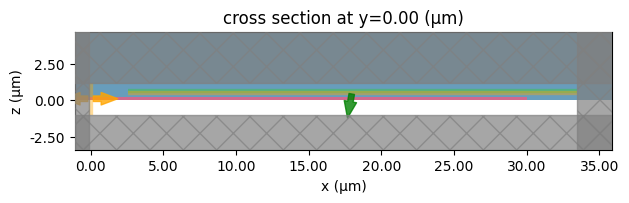

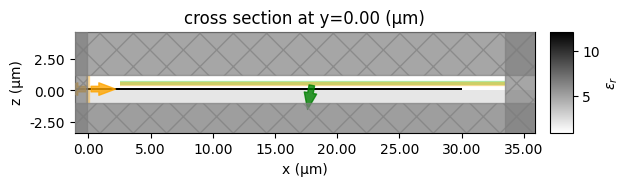

In [31]:
basesim.plot(y=0)
basesim.plot_eps(y=0)
plt.show()

We can see that PhotonForge has automatically generated the simulation contains background structures for this technology stack, and has added a Gaussian beam source (green) and a waveguide mode monitor (orange).

## 3. Grating coupler simulation

Now that we have our base simulation with the objects that won't change during optimization, we can modify the simulation to include the grating structure and run 2D grating simulations.

We will first convert the base simulation from 3D to 2D, and we will also remove the field monitor below the Gaussian source because it's not needed for optimization (it is automatically added by PhotonForge for computing S-parameters):

In [32]:
# Update the simulation size so that it is 2D
size = (basesim.size[0], 0, basesim.size[2])

# Update the boundary spec for 2D simulations
boundary_spec = basesim.boundary_spec.updated_copy(
    y=td.Boundary(minus=td.Periodic(), plus=td.Periodic()),
)

# Update the monitor size
monitors = []
for monitor in basesim.monitors:
    # We will remove the field monitor since it's not needed during optimization
    if monitor.type == "ModeMonitor":
        mon_size = (monitor.size[0], td.inf, monitor.size[2])
        monitors.append(monitor.updated_copy(size=mon_size))

basesim = basesim.updated_copy(
    size=size,
    boundary_spec=boundary_spec,
    monitors=monitors,
)

The size of the simulation is now two dimensional:

In [33]:
print(basesim.size)

(33.534, 0.0, 2.222)


Next, we add in the grating coupler structure. Below are the starting parameters for our grating coupler, taken from \[1]. 

In [34]:
period = 0.63
gc_len = 15.5
ncells = int(round(gc_len / period))
fill_factor = 0.5

gc_widths = np.ones(shape=ncells) * period * fill_factor
gc_gaps = period - gc_widths

From the technology, we get the z-bounds of the grating etch

In [35]:
# Extract the layers and their bounds from the extrusion specs
extrusion_layers = [ex.mask_spec.layer for ex in tech.extrusion_specs]
extrusion_bounds = [ex.limits for ex in tech.extrusion_specs]

# Get the slab, core, and etch bounds
slabbounds = extrusion_bounds[extrusion_layers.index(tech.layers["SLAB"].layer)]
corebounds = extrusion_bounds[extrusion_layers.index(tech.layers["WG_CORE"].layer)]
etch_zbounds = (slabbounds[1], corebounds[1])

Now, we create a function that adds the grating teeth to the simulation

In [36]:
def gc_sim(
    gc_gaps: np.ndarray,
    gc_widths: np.ndarray,
    basesim: td.Simulation = basesim,
    gc_startx: float = 5,
):
    """Returns a 2D grating simulation for optimization.

    Params:
    -------
    gc_gaps : np.ndarray
        Widths of the partially-etched regions
    gc_widths : np.ndarray
        Widths of the unetched regions
    basesim : td.Simulation
        Base simulation to update
    gc_startx : float
        The position of where the grating begins.
    """

    # Add the grating teeth to the simulation
    grating_structures = []
    cx = gc_startx
    for w, g in zip(gc_widths, gc_gaps):
        cx += g / 2
        grating_structures.append(
            td.Structure(
                geometry=td.Box.from_bounds(
                    rmin=(cx - g / 2, -td.inf, etch_zbounds[0]),
                    rmax=(cx + g / 2, td.inf, etch_zbounds[1]),
                ),
                medium=td.Medium(permittivity=1.0),
            )
        )
        cx += g / 2 + w
    structures = list(basesim.structures) + grating_structures

    # Etch away the remaining waveguide layer
    structures.append(
        td.Structure(
            geometry=td.Box.from_bounds(
                rmin=(cx, -td.inf, corebounds[0]), rmax=(1e3, td.inf, corebounds[1])
            ),
            medium=td.Medium(permittivity=1.0),
        )
    )

    return basesim.updated_copy(structures=structures)

Let's test the gc simulation to make sure it's working. First let's view the simulation with the grating.

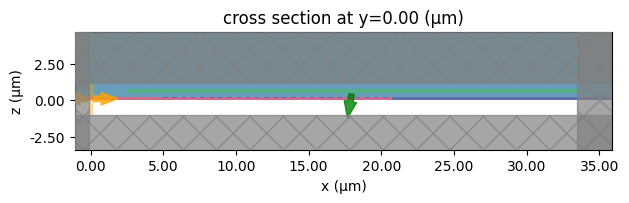

In [37]:
# test gc sim
testsim = gc_sim(
    gc_gaps,
    gc_widths,
)

testsim.plot(y=0)
plt.show()

The source position is likely sub-optimal, but let's run the simulation to make sure there aren't any errors in the setup.

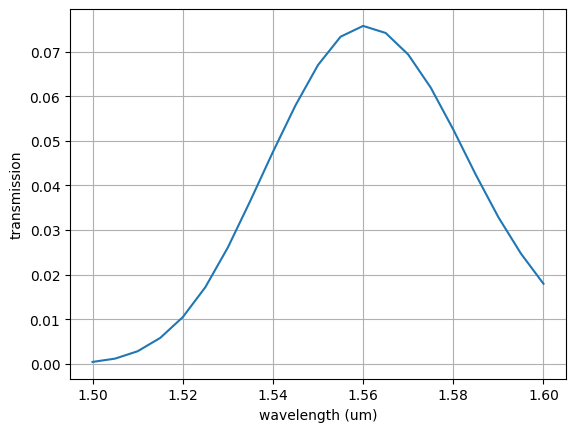

In [38]:
sim_data = td.web.run(testsim, task_name="testgc", path="simdata/data.hdf5", verbose=False)

# Plot transmission
amps = sim_data["P0"].amps.sel(direction="-")
T = amps.abs**2
f, ax = plt.subplots()
ax.plot(td.C_0 / T.f, T)
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("transmission")
ax.grid()

The initial simulation looks correct. 

Now let's sweep the source position and find the position for the best coupling.

In [39]:
# sweep source position for best coupling
fiber_pos = np.linspace(5, 15, 11)

# Generate simulations with updated fiber source positions
sims = []
for fpos in fiber_pos:
    source = testsim.sources[0]
    source = source.updated_copy(center=(fpos, source.center[1], source.center[2]))
    sims.append(testsim.updated_copy(sources=[source]))

# Consolidate simulations into a dict for passing to td.web.run
gcsims = {f"fiber_pos{fpos}": sim for fpos, sim in zip(fiber_pos, sims)}

# Run the batch of simulations.
batchdata = td.web.run(gcsims, path="simdata", verbose=False)

In [40]:
# Get transmission at the center wavelength vs. source position
centerwl = 1.55
T_centerwl = []
for key, simdata in batchdata.items():
    amps = simdata["P0"].amps.sel(direction="-")
    T = amps.abs**2
    T_centerwl.append(T.interp(f=td.C_0 / centerwl).data[0])

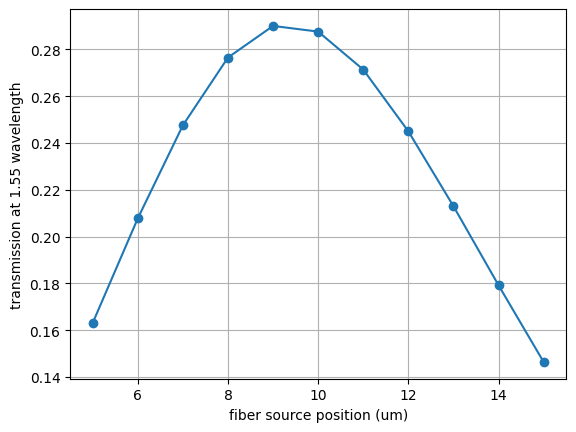

In [41]:
f, ax = plt.subplots()
ax.plot(fiber_pos, T_centerwl, "-o")
ax.set_xlabel("fiber source position (um)")
ax.set_ylabel(f"transmission at {centerwl} wavelength")
ax.grid()
plt.show()

It looks like a good source position is 9 um. Let's update the base simulation, then we will be ready for adjoint optimizations.

In [42]:
# update source position
best_fiber_pos = fiber_pos[np.argmax(T_centerwl)]
source = basesim.sources[0]
source = source.updated_copy(center=(best_fiber_pos, source.center[1], source.center[2]))
basesim = basesim.updated_copy(sources=[source])

## 4. Adjoint optimization

First we'll define an objective value to improve. For example, it can be improving the worst case loss within a specified bandwidth.

The `smooth_min()` function provides a differentiable calculation of the minimum of a set of values. Differentiability is important for gradient descent to work.

In [43]:
def worstloss(simdata, wl_range):
    """Returns the worst transmission across measured frequencies from the monitor"""
    freqrange = td.C_0 / np.array(wl_range)
    amps = simdata["P0"].amps.sel(direction="-", f=slice(freqrange[0], freqrange[1])).data
    T = np.abs(amps) ** 2
    return smooth_min(T, tau=1e-2)

We will need to wrap this value within an objective function that takes in the optimization parameters as a single array. For compatibility with Autograd, the package that handles differentiation through general Python code, it is important that the optimization parameters are passed into the objective function as positional arguments. If interested, please see [this article](https://hs.flexcompute.com/adjoint-for-tidy3d) for an overview of how Autograd fits into the Tidy3D inverse design pipeline.

Before making that function, let's make a couple of helper functions that will convert between the design as a dictionary, and the design as an array. This will make it easier for us to keep track of the parameters outside of the optimization loop.

In [44]:
def design_to_array(design: dict[str, np.ndarray]) -> tuple[np.ndarray, tuple[int, int]]:
    """Converts design parameters into a single array"""
    gc_gaps = design["gc_gaps"]
    gc_widths = design["gc_widths"]
    array = np.hstack([gc_gaps, gc_widths])
    lengths = (
        len(gc_gaps),
        len(gc_widths),
    )
    return array, lengths


def array_to_design(array: np.ndarray, lengths: tuple[int, int]) -> dict[str, np.ndarray]:
    """Converts array back to design parameters"""
    len_gaps, len_widths = lengths
    idx = 0
    design = {}
    design["gc_gaps"] = array[idx : idx + len_gaps]
    idx += len_gaps
    design["gc_widths"] = array[idx : idx + len_widths]
    return design

Now we make an objective function, which is just a wrapper around our objective value. The function
1. Takes in the parameters as a single array (needed for compatibility with Autograd), and converts them to their constituent design parameters.
2. Creates and runs a simulation from the design parameters.
3. Calls and returns our objective value function.

In [45]:
def objective(params_array: np.ndarray, param_lengths, wl_range):
    """The objective function for optimization. Creates the simulation, and returns the loss."""
    # first convert the parameter array to a dictionary for passing to the simulation maker
    design = array_to_design(params_array, param_lengths)

    # then create and run the simulation
    sim = gc_sim(**design, basesim=basesim)
    simdata = td.web.run(sim, task_name="gcopt", path="simdata/gc.hdf5", verbose=False)

    # finally return the objective value
    return worstloss(simdata, wl_range=wl_range)

A real PIC platform will also have minimum feature constraints. We'll define a minimum line (width) and gap (space) here, and enforce these constraints inside of the optimization loop through parameter clipping. Clipping will prevent values from decreasing below the minimum line and gap.

In [46]:
min_line = 0.15
min_space = 0.2


def minfeat_cliparray(design, min_line=min_line, min_space=min_space):
    """This function returns a single array of minimum line and space for clipping."""
    _, param_lengths = design_to_array(design)
    min_spaces = min_space * np.ones(shape=param_lengths[0])
    min_lines = min_line * np.ones(shape=param_lengths[1])
    return np.concatenate((min_spaces, min_lines))

Now we can assemble the various pieces together into a main optimization loop.

Along with the starting design and objective function, we will also choose parameters for our optimizer such as the number of steps, learning rate, and optimizer to use. For the optimizer, we use the Adam algorithm implemented by the [Optax package](https://optax.readthedocs.io/en/latest/).

The hard work of evaluating the gradient is handled by Tidy3D's adjoint functionality (wrapped with Autograd for chain rule tracing through general Python code). The parameters are then updated using a specified optimizer method. In this case, we are using Optax for handling the updates.

In [47]:
# The wavelength range to optimize for
wl_range = (1.545, 1.555)

# Optimization parameters
learning_rate = 1e-2
num_steps = 40

# The starting grating design
design0 = {
    "gc_gaps": gc_gaps,
    "gc_widths": gc_widths,
}

# Choice of optimizer to use
optimizer = optax.adam

# Initialize the optimizer with starting parameters
params_array0, param_lengths = design_to_array(design0)
params_array = np.array(params_array0).copy()
optimizer = optimizer(learning_rate=learning_rate)
opt_state = optimizer.init(params_array)

# Create the minimum feature size array for clipping
minfeatarr = minfeat_cliparray(design=design0)

# Arrays that store the optimization history
objective_history = []
param_history = [params_array]
gradient_history = []

# To use Autograd to calculate the gradient of our objective function, we wrap it within
# Autograd's value_and_grad() function.
obj_fun = partial(objective, param_lengths=param_lengths, wl_range=wl_range)
grad_fn = ag.value_and_grad(obj_fun)


Let's run the optimization for 40 iterations at a learning rate of 1e-2. We will optimize for a narrow bandwidth of 10 nm, from 1545 to 1555 nm wavelength. Feel free to experiment with these values on your own.

In [49]:
for ii in range(num_steps):
    print(f"step = {ii + 1}")

    # Evaluate the current value and gradient of our objective function with the current parameters.
    value, gradient = grad_fn(params_array)

    # Print the outputs
    print(f"\tJ = {value:.4e}")
    print(f"\tgrad_norm = {np.linalg.norm(gradient):.4e}")

    # Compute and apply updates to the parameters based on the computed gradient.
    # The Optax Adam optimizer is used to compute and apply the updates.
    # Note that the gradient is negated for maximizing the objective (the default behavior is to minimize).
    updates, opt_state = optimizer.update(-gradient, opt_state, params_array)
    params_array = optax.apply_updates(params_array, updates)
    params_array = np.array(params_array)

    # Enforce DRC constraints by clipping the parameters.
    np.clip(params_array, minfeatarr, None, out=params_array)

    # Save the results of this iteration step to the history.
    objective_history.append(value)
    param_history.append(params_array)
    gradient_history.append(gradient)

step = 1
	J = 2.6875e-01
	grad_norm = 2.7844e+00
step = 2
	J = 1.7482e-01
	grad_norm = 4.3962e+00
step = 3
	J = 2.4174e-01
	grad_norm = 3.5628e+00
step = 4
	J = 2.9479e-01
	grad_norm = 1.0747e+00
step = 5
	J = 2.4486e-01
	grad_norm = 3.4810e+00
step = 6
	J = 2.4816e-01
	grad_norm = 3.3931e+00
step = 7
	J = 2.8747e-01
	grad_norm = 1.8932e+00
step = 8
	J = 2.9107e-01
	grad_norm = 1.6187e+00
step = 9
	J = 2.6748e-01
	grad_norm = 2.8400e+00
step = 10
	J = 2.6988e-01
	grad_norm = 2.7721e+00
step = 11
	J = 2.9043e-01
	grad_norm = 1.6708e+00
step = 12
	J = 2.9712e-01
	grad_norm = 8.3142e-01
step = 13
	J = 2.8138e-01
	grad_norm = 2.3528e+00
step = 14
	J = 2.7857e-01
	grad_norm = 2.5038e+00
step = 15
	J = 2.9163e-01
	grad_norm = 1.4817e+00
step = 16
	J = 2.9914e-01
	grad_norm = 4.5497e-01
step = 17
	J = 2.9055e-01
	grad_norm = 1.5387e+00
step = 18
	J = 2.8647e-01
	grad_norm = 1.9125e+00
step = 19
	J = 2.9192e-01
	grad_norm = 1.4882e+00
step = 20
	J = 2.9868e-01
	grad_norm = 5.3988e-01
step = 21

10:35:15 CEST WARNING: No connection: Retrying for 180 seconds.                 

	J = 3.0087e-01
	grad_norm = 7.1528e-01
step = 32
	J = 3.0150e-01
	grad_norm = 4.7725e-01
step = 33
	J = 2.9944e-01
	grad_norm = 1.0396e+00
step = 34
	J = 3.0016e-01
	grad_norm = 9.4432e-01
step = 35
	J = 3.0242e-01
	grad_norm = 2.5177e-01
step = 36
	J = 3.0157e-01
	grad_norm = 7.5008e-01
step = 37
	J = 3.0061e-01
	grad_norm = 1.0277e+00
step = 38
	J = 3.0278e-01
	grad_norm = 4.6889e-01
step = 39
	J = 3.0295e-01
	grad_norm = 4.4630e-01
step = 40
	J = 3.0199e-01
	grad_norm = 8.3475e-01


Once the optimization is complete we can view the results:

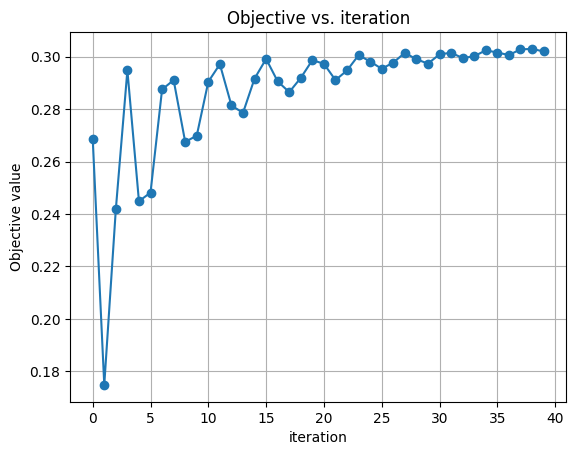

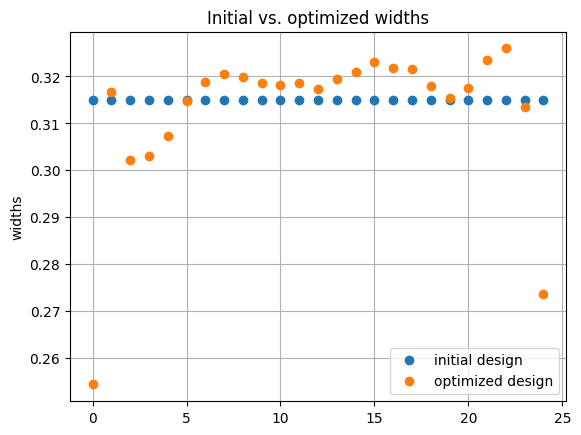

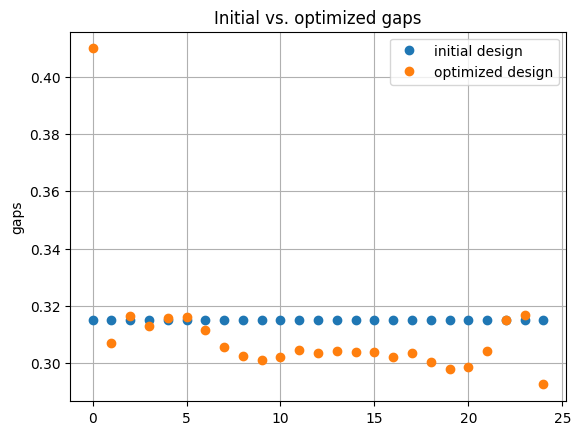

In [50]:
# Plot the objective value versus iteration.
f, ax = plt.subplots()
ax.plot(objective_history, "-o")
ax.set_xlabel("iteration")
ax.set_ylabel("Objective value")
ax.grid()
ax.set_title("Objective vs. iteration")

# Select the best design parameters.
best_params = param_history[np.argmax(objective_history)]
_, param_lengths = design_to_array(design0)
best_design = array_to_design(best_params, param_lengths)

# Compare the starting and final params.
f, ax = plt.subplots()
ax.plot(design0["gc_widths"], "o", label="initial design")
ax.plot(best_design["gc_widths"], "o", label="optimized design")
ax.set_ylabel("widths")
ax.grid()
ax.legend()
ax.set_title("Initial vs. optimized widths")

f, ax = plt.subplots()
ax.plot(design0["gc_gaps"], "o", label="initial design")
ax.plot(best_design["gc_gaps"], "o", label="optimized design")
ax.set_ylabel("gaps")
ax.grid()
ax.legend()
ax.set_title("Initial vs. optimized gaps")

plt.show()

Finally, we can simulate the optimized design, and compare it with the initial design.

In [51]:
sim_startdesign = gc_sim(**design0, basesim=basesim)
simdata_startdesign = td.web.run(
    sim_startdesign, task_name="gcopt", path="simdata/gcstart.hdf5", verbose=False
)
sim_bestdesign = gc_sim(**best_design, basesim=basesim)
simdata_bestdesign = td.web.run(
    sim_bestdesign, task_name="gcopt", path="simdata/gcbest.hdf5", verbose=False
)

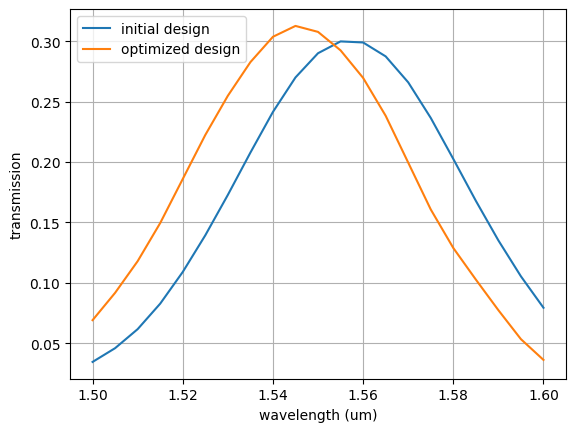

In [52]:
# Plot final transmission, compare to the initial design
amps_startdesign = simdata_startdesign["P0"].amps.sel(direction="-")
T_startdesign = amps_startdesign.abs**2
amps_bestdesign = simdata_bestdesign["P0"].amps.sel(direction="-")
T_bestdesign = amps_bestdesign.abs**2

f, ax = plt.subplots()
ax.plot(td.C_0 / T_startdesign.f, T_startdesign, label="initial design")
ax.plot(td.C_0 / T_bestdesign.f, T_bestdesign, label="optimized design")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("transmission")
ax.grid()
ax.legend()

plt.show()

We can see that the final design has centered the transmission spectrum on our design wavelength, and slightly improved the coupling efficiency. More improvement could be possible by experimenting with the optimization hyperparameters, such as the starting design or the coupling bandwidth. Feel free to experiment if you would like and see if you can improve the design even more.